# Handwritten Digit Recognition - 01: EDA

MNIST is the classic image-classification benchmark: 28x28 grayscale images of handwritten digits 0-9. This project trains a small convolutional neural network from scratch. To stay self-contained and fast, we ship a committed subset (`data/mnist_subset.npz`, 10,000 train / 2,000 test) sampled from the full MNIST set with a fixed seed.

In [1]:
import sys, numpy as np
import matplotlib.pyplot as plt
sys.path.append('.')
import utils
Xtr, ytr, Xte, yte = utils.load_subset()
print('train:', Xtr.shape, ' test:', Xte.shape)
print('pixel range:', Xtr.min(), '-', Xtr.max(), ' dtype:', Xtr.dtype)

train: (10000, 28, 28)  test: (2000, 28, 28)
pixel range: 0 - 255  dtype: uint8


## 1. A grid of sample digits

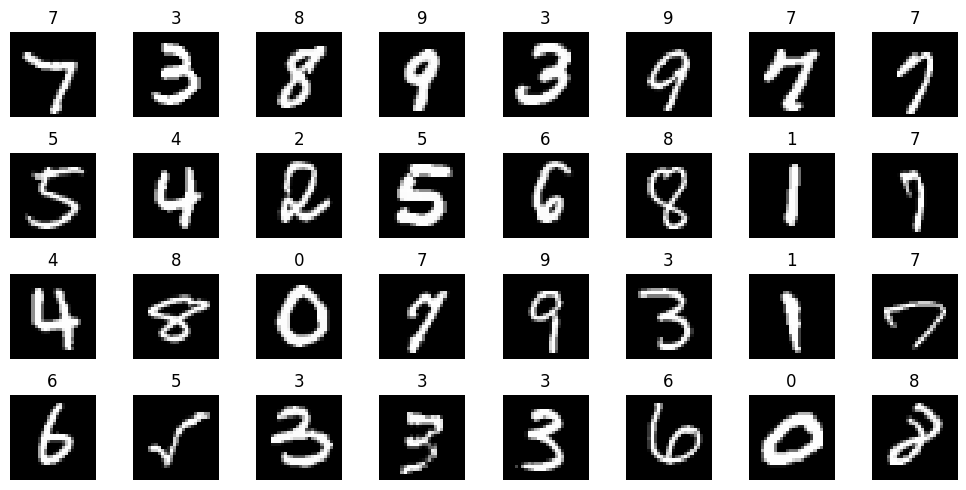

In [2]:
fig, ax = plt.subplots(4, 8, figsize=(10,5))
for a, i in zip(ax.ravel(), range(32)):
    a.imshow(Xtr[i], cmap='gray'); a.set_title(str(ytr[i])); a.axis('off')
plt.tight_layout(); plt.show()

## 2. Class balance

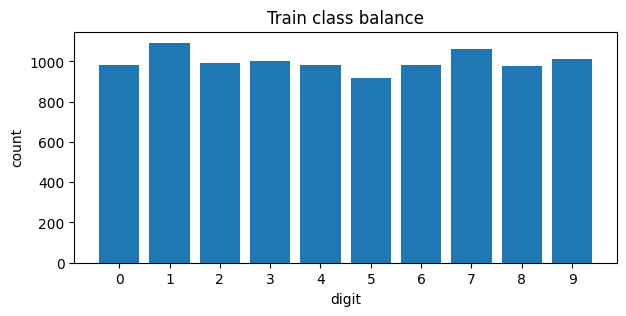

digit 0 : 984
digit 1 : 1093
digit 2 : 994
digit 3 : 1000
digit 4 : 980
digit 5 : 919
digit 6 : 981
digit 7 : 1060
digit 8 : 979
digit 9 : 1010


In [3]:
vals, counts = np.unique(ytr, return_counts=True)
plt.figure(figsize=(7,3)); plt.bar(vals, counts)
plt.xticks(vals); plt.xlabel('digit'); plt.ylabel('count'); plt.title('Train class balance'); plt.show()
for v,c in zip(vals,counts): print('digit', v, ':', c)

## 3. Average image per digit

Mean of all training images for each class shows the 'prototype' shape.

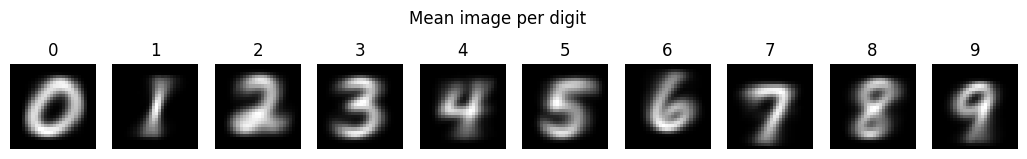

In [4]:
fig, ax = plt.subplots(1, 10, figsize=(13,2))
for d in range(10):
    ax[d].imshow(Xtr[ytr==d].mean(0), cmap='gray'); ax[d].set_title(str(d)); ax[d].axis('off')
plt.suptitle('Mean image per digit'); plt.show()

## 4. Pixel intensity distribution

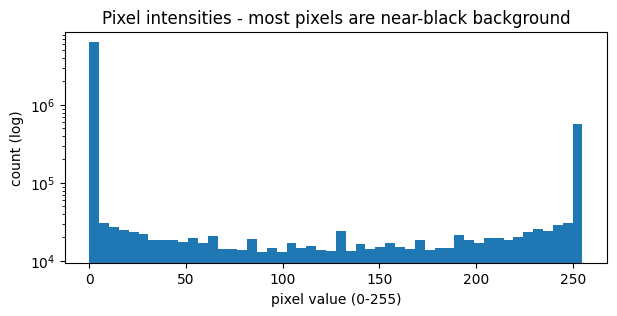

% zero (background) pixels: 80.9%


In [5]:
plt.figure(figsize=(7,3)); plt.hist(Xtr.ravel(), bins=50)
plt.yscale('log'); plt.xlabel('pixel value (0-255)'); plt.ylabel('count (log)')
plt.title('Pixel intensities - most pixels are near-black background'); plt.show()
print('%% zero (background) pixels: %.1f%%' % (100*(Xtr==0).mean()))

### Findings
- Classes are roughly balanced (each digit ~1,000 of 10,000 train images).
- The mean-image-per-digit panel already shows clean prototypes, so the digits are well separated.
- Images are mostly black background: the ink is a small fraction of each 28x28 frame.